# Trader Performance Analysis Based on Bitcoin Market Sentiment

## Objective
Analyze the relationship between Bitcoin Fear & Greed sentiment...

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

print("Trader Data Shape:", df.shape)
print("Fear & Greed Shape:", fg.shape)

Trader Data Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


In [6]:
df['trade_date'] = pd.to_datetime(
    df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

fg['trade_date'] = pd.to_datetime(
    fg['date']
).dt.date

In [7]:
merged = pd.merge(
    df,
    fg[['trade_date', 'classification', 'value']],
    on='trade_date',
    how='left'
)

print(merged.shape)
merged.head()

(211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


In [8]:
non_zero = merged[merged['Closed PnL'] != 0]

summary_fixed = non_zero.groupby('classification')['Closed PnL'].agg(
    ['count', 'mean', 'sum', 'median']
).sort_values('sum', ascending=False)
nex
summary_fixed

,count,mean,sum,median
classification,,,,
Fear,29808,112.625988,3.357155e+06,6.350483
Extreme Greed,20853,130.205309,2.715171e+06,8.530740
Greed,25176,85.403927,2.150129e+06,4.927600
Neutral,18159,71.199993,1.292921e+06,4.583458
Extreme Fear,10406,71.027316,7.391102e+05,6.388050


In [9]:
profit_rate = merged.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).mean() * 100
)

profit_rate.sort_values(ascending=False)

classification
Extreme Greed    46.494299
Fear             42.076750
Neutral          39.699093
Greed            38.482794
Extreme Fear     37.060748
dtype: float64

exposure = merged.groupby('classification').agg({
    'Size USD': ['mean', 'sum'],
    'Closed PnL': 'sum'
})

exposure

In [ ]:
# Bitcoin Market Sentiment vs Trader Performance (Hyperliquid)

## Objective
Analyze how Bitcoin Fear & Greed sentiment impacts trader behavior and profitability using Hyperliquid trading data.

## Datasets Used
- Hyperliquid historical trades dataset
- Bitcoin Fear & Greed Index

In [12]:
summary = merged.groupby('classification')['Closed PnL'].agg(['count','mean','sum','median'])

win_rate = merged.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).mean()*100
)

exposure = merged.groupby('classification').agg({
    'Size USD': ['mean','sum']
})

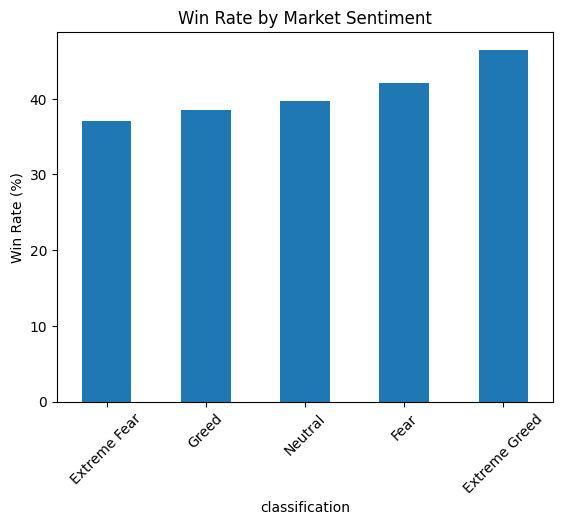

In [13]:
import matplotlib.pyplot as plt

win_rate.sort_values().plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

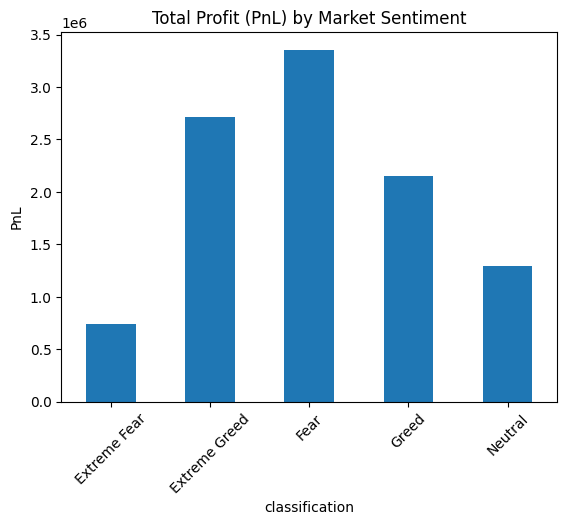

In [14]:
summary['sum'].plot(kind='bar')
plt.title("Total Profit (PnL) by Market Sentiment")
plt.ylabel("PnL")
plt.xticks(rotation=45)
plt.show()

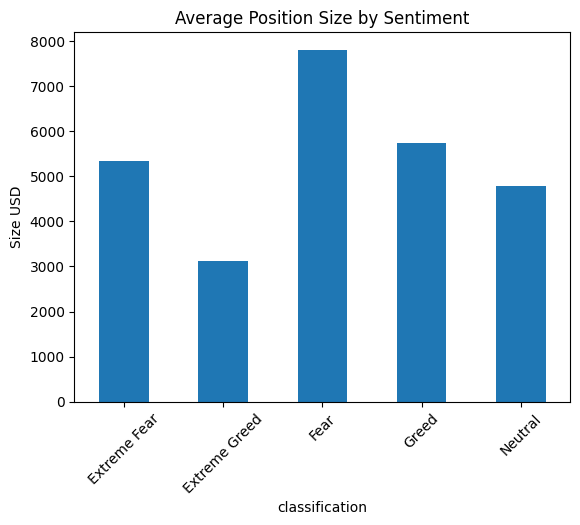

In [15]:
exposure['Size USD']['mean'].plot(kind='bar')
plt.title("Average Position Size by Sentiment")
plt.ylabel("Size USD")
plt.xticks(rotation=45)
plt.show()

## Key Findings

- Traders take the largest position sizes during **Fear**, indicating aggressive buying/selling during uncertainty.
- **Extreme Greed** shows the highest win rate, suggesting more stable and trend-following market conditions.
- **Extreme Fear** has the lowest win rate, indicating highly volatile and inefficient trading behavior.
- Total profitability is highest during Fear due to higher trading activity and exposure.
- Market sentiment has a clear influence on both risk-taking behavior and trading performance.

## Conclusion

This analysis shows that trader behavior is strongly influenced by Bitcoin market sentiment.

Instead of acting rationally, traders tend to increase exposure during Fear conditions, while performance (win rate) improves during Extreme Greed phases.

This suggests that:
- Fear drives high activity but not optimal efficiency
- Greed phases are more structured and profitable for execution
- Emotional market states significantly impact trading decisions